<a href="https://colab.research.google.com/github/JihaeChun/RL_202512_20team/blob/main/%EA%B0%95%ED%99%94%ED%95%99%EC%8A%B5_%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8_1_Qlearning_MDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#프로젝트 data 불러오기!
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
file_path1 = '/content/drive/MyDrive/Colab Notebooks/data1.csv'
file_path2 = '/content/drive/MyDrive/Colab Notebooks/data2.csv'
data1=pd.read_csv(file_path1)
data2=pd.read_csv(file_path2)

Mounted at /content/drive


In [2]:
#train/test 데이터 나누기
from sklearn.model_selection import train_test_split
cust_train_df, cust_test_df = train_test_split(data1,test_size=0.3, random_state=42, shuffle=True)

In [3]:
cust_train_df_id = set(cust_train_df['KEY'])
cust_test_df_id  = set(cust_test_df['KEY'])

lms_train_df = data2[data2['KEY'].isin(cust_train_df_id)].copy()
lms_test_df  = data2[data2['KEY'].isin(cust_test_df_id)].copy()

In [5]:
#1단계: 고객 + 발송데이터 merge (증권번호 기준)
#    - key: 증권번호
#    - 보상은 고객 데이터의 '갱신여부' 사용

cust_cols_for_merge = [
    'KEY', '성별', '연령대', '결혼여부', '자녀운전여부',
    '차종코드', '이전유입채널', '신규갱신', '갱신연차', '갱신여부'
]

train_merged = pd.merge(
    lms_train_df,
    cust_train_df[cust_cols_for_merge],
    on='KEY',
    how='left'
)

test_merged = pd.merge(
    lms_test_df,
    cust_test_df[cust_cols_for_merge],
    on='KEY',
    how='left'
)

#print("Train merge shape:", train_merged.shape)
#print(train_merged.head())

#print("Test merge shape:", test_merged.shape)
#print(test_merged.head())

def yn_to_num(x):
    if isinstance(x, str):
        x = x.strip()
        if x.upper() == 'Y':
            return 1.0
        if x.upper() == 'N':
            return 0.0
    # 그 외 값(결측, 이상값)은 일단 0으로 처리
    return 0.0

train_merged['갱신여부_num'] = train_merged['갱신여부'].apply(yn_to_num)
test_merged['갱신여부_num']  = test_merged['갱신여부'].apply(yn_to_num)

#print("=== 갱신여부(Y/N) → 숫자 변환 샘플 ===")
#display(train_merged[['갱신여부', '갱신여부_num']].head(10))

print("\n=== 갱신여부_num 분포 (train) ===")
print(train_merged['갱신여부_num'].value_counts(dropna=False))


=== 갱신여부_num 분포 (train) ===
갱신여부_num
1.0    24911
0.0     6120
Name: count, dtype: int64


q-learning
- state : data1에서 상태(성별,연령대,결혼여부,자녀운전여부,차종코드,이전유입채널,갱신연차,만기까지남은일수)
- action : “어떤 캠페인을 보냈을 때 갱신 보상이 얼마나 좋았나”를 Q로 학습
- reward : 갱신여부를 보상으로 사용 (이 증권의 최종 결과)
*        갱신여부 = 1 → reward = 1.0 / 갱신여부 = 0 → reward = 0.0

- 에피소드 길이를 1로 두고(한 샘플이 한 번의 의사결정),
Q-learning 업데이트는:
*     𝑄(𝑠,𝑎)←𝑄(𝑠,𝑎)+𝛼(𝑟−𝑄(𝑠,𝑎)),  Q(s,a)←Q(s,a)+α(r−Q(s,a))
*     (다음 상태가 없으니 gamma * max Q(next_state) 부분이 빠진 형태)

In [6]:
#2단계: state / action / reward 정의 + 인코딩
# state: 고객 특성 + 만기까지남은일수
# action: 캠페인번호
# reward: 갱신여부(1/0)

state_cols = [
    '성별', '연령대', '결혼여부', '자녀운전여부',
    '차종코드', '이전유입채널', '갱신연차', '만기까지남은일수'
]

# action: 캠페인번호
action_col = '캠페인번호'

# reward: 숫자로 변환된 갱신여부
reward_col = '갱신여부_num'

In [8]:
for c in state_cols + [action_col]:
    if train_merged[c].isnull().any():
        train_merged[c] = train_merged[c].fillna('UNKNOWN')
    if test_merged[c].isnull().any():
        test_merged[c] = test_merged[c].fillna('UNKNOWN')

# ================================
# 8. 범주형 → 정수 ID 인코딩
#    - train 기준으로 encoder 만들고
#    - train/test 모두 *_id 컬럼으로 변환
# ================================
encoders = {}

for c in state_cols + [action_col]:
    train_vals = train_merged[c].astype(str)
    test_vals  = test_merged[c].astype(str)

    cats = sorted(train_vals.unique())
    encoder = {v: i for i, v in enumerate(cats)}
    encoders[c] = encoder

    train_merged[c + '_id'] = train_vals.map(encoder)

    # test는 train에 없는 값이 있을 수 있으니 -1로
    test_merged[c + '_id'] = test_vals.map(lambda v: encoder.get(v, -1))

#print("인코딩된 train_merged 예시:")
#display(train_merged.head())

In [9]:
# 3단계: Q-learning 학습 + TD error 저장
# 에피소드 길이를 1로 보고,
#“이 상태에서 이 캠페인을 보냈을 때 → 갱신여부가 보상” 으로 Q(s,a)를 업데이트

from collections import defaultdict
import numpy as np


# 액션(캠페인) 개수
n_actions = len(encoders[action_col])
print("캠페인(액션) 개수:", n_actions)

Q = defaultdict(lambda: np.zeros(n_actions, dtype=float))

alpha = 0.1          # 학습률
num_epochs = 30      # 데이터 여러 번 반복 학습
avg_td_errors = []   # epoch별 평균 |TD error|

print("=== reward(갱신여부_num) 분포 (train) ===")
print(train_merged[reward_col].value_counts(dropna=False))

for epoch in range(num_epochs):
    # 에폭마다 데이터 순서를 섞어서 학습
    shuffled = train_merged.sample(frac=1.0, random_state=epoch)

    total_td_error = 0.0
    cnt = 0

    for _, row in shuffled.iterrows():
        # 상태: *_id 들을 튜플로
        state = tuple(row[c + '_id'] for c in state_cols)
        action_idx = int(row[action_col + '_id'])
        reward = float(row[reward_col])  # 0.0 또는 1.0

        # train에 없는 캠페인(-1)은 스킵
        if action_idx < 0:
            continue

        # TD target = r (다음 상태 없는 bandit 구조)
        td_target = reward
        td_error = td_target - Q[state][action_idx]

        # Q 업데이트
        Q[state][action_idx] += alpha * td_error

        total_td_error += abs(td_error)
        cnt += 1

    avg_td_error = total_td_error / max(cnt, 1)
    avg_td_errors.append(avg_td_error)
    print(f"[Epoch {epoch+1}/{num_epochs}] 평균 |TD error| = {avg_td_error:.4f}")

캠페인(액션) 개수: 14
=== reward(갱신여부_num) 분포 (train) ===
갱신여부_num
1.0    24911
0.0     6120
Name: count, dtype: int64
[Epoch 1/30] 평균 |TD error| = 0.7270
[Epoch 2/30] 평균 |TD error| = 0.5723
[Epoch 3/30] 평균 |TD error| = 0.4782
[Epoch 4/30] 평균 |TD error| = 0.4130
[Epoch 5/30] 평균 |TD error| = 0.3642
[Epoch 6/30] 평균 |TD error| = 0.3264
[Epoch 7/30] 평균 |TD error| = 0.2962
[Epoch 8/30] 평균 |TD error| = 0.2714
[Epoch 9/30] 평균 |TD error| = 0.2507
[Epoch 10/30] 평균 |TD error| = 0.2334
[Epoch 11/30] 평균 |TD error| = 0.2190
[Epoch 12/30] 평균 |TD error| = 0.2060
[Epoch 13/30] 평균 |TD error| = 0.1954
[Epoch 14/30] 평균 |TD error| = 0.1862
[Epoch 15/30] 평균 |TD error| = 0.1778
[Epoch 16/30] 평균 |TD error| = 0.1708
[Epoch 17/30] 평균 |TD error| = 0.1647
[Epoch 18/30] 평균 |TD error| = 0.1590
[Epoch 19/30] 평균 |TD error| = 0.1542
[Epoch 20/30] 평균 |TD error| = 0.1496
[Epoch 21/30] 평균 |TD error| = 0.1460
[Epoch 22/30] 평균 |TD error| = 0.1425
[Epoch 23/30] 평균 |TD error| = 0.1395
[Epoch 24/30] 평균 |TD error| = 0.1369
[Epoch 25

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

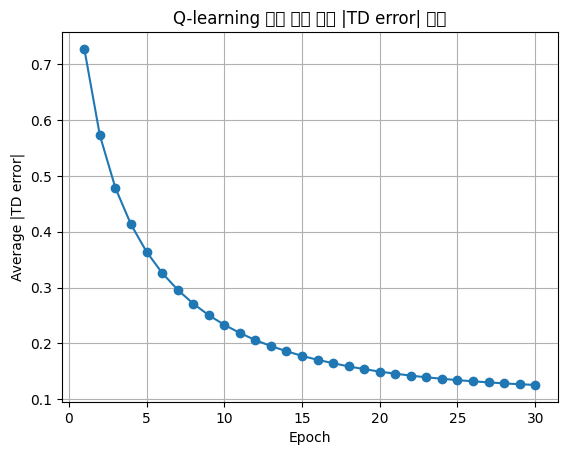

In [10]:
# TD Error 학습 곡선 그래프
# 에폭이 증가할수록 Average |TD error|가 줄어들면→ Q(s,a)가 점점 안정적으로 수렴하는 과정이라고 설명하면 됨.
#“초기에는 상태-행동에 대한 Q값이 랜덤에 가깝기 때문에 TD error가 크게 나타나지만,
#여러 epoch 동안 데이터를 반복 학습하면서 TD error가 감소하는 모습을 확인할 수 있습니다.
#이는 Q-learning이 캠페인별 기대 갱신 보상에 맞게 점점 수렴해가는 과정으로 볼 수 있습니다.”

import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs + 1), avg_td_errors, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average |TD error|")
plt.title("Q-learning 학습 동안 평균 |TD error| 변화")
plt.grid(True)
plt.show()

In [13]:
# 4단계: 실제 행동 vs Q가 고른 행동
actual_q_list = []
best_q_list = []
renew_list = []

for _, row in test_merged.iterrows():
    state = tuple(row[c + '_id'] for c in state_cols)
    act_idx = int(row[action_col + '_id'])

    # train에 없던 캠페인(-1)은 스킵
    if act_idx < 0:
        continue

    q_values = Q[state]
    best_idx = int(np.argmax(q_values))

    reward = float(row[reward_col])  # 0.0 / 1.0

    actual_q_list.append(q_values[act_idx])
    best_q_list.append(q_values[best_idx])
    renew_list.append(reward)

print("=== 테스트 데이터 기준 간단 평가 결과 ===")
print("실제 행동 Q 평균       :", np.mean(actual_q_list))
print("Q가 가장 큰 행동 Q 평균:", np.mean(best_q_list))
print("실제 갱신률(참고)      :", np.mean(renew_list))


#“테스트 데이터에서 실제로 집행된 캠페인의 평균 Q값과,
#Q-learning이 ‘가장 좋다고 판단한 캠페인’의 평균 Q값을 비교해 보면
#최적 캠페인 쪽 평균 Q가 더 높게 나타났고,
#이는 학습된 정책이 기존 행동보다 더 높은 기대 갱신 보상을 갖는
#행동을 선호하도록 업데이트되었음을 알수있다.”

=== 테스트 데이터 기준 간단 평가 결과 ===
실제 행동 Q 평균       : 0.5483484333642211
Q가 가장 큰 행동 Q 평균: 0.5629274329898327
실제 갱신률(참고)      : 0.8149619063057222



---
---
앞에 학습으로는 갱신여부만 알 수 있지 언제보내야지 갱신확률을 높일지는 알 수 없음 이에 다른 학습을 진행
---
---




In [14]:
# 5단계 - "언제 보내야 갱신이 될까?" --> Multi-Step MDP

# State 구성 (D-day	만기까지 남은 일수
#고객 속성	성별 / 연령대 / 결혼 / 자녀운전 / 차종 / 유입채널 / 갱신연차
#최근 발송 여부	직전 1~3일간 캠페인 보냈는지
# Action 구성 / 0	오늘 발송 안 함 / 1	오늘 발송 함
# Reward 구성 / 매일은 reward = 0 / 만기일에 갱신 성공 → reward = +1 / 갱신 실패 → reward = 0
# Episode 정의 / D-day: 45 → 44 → … → 0 /  매일 “발송?” or “발송 안 함?”

import numpy as np
from collections import defaultdict

# 행동: 0=발송 안 함, 1=발송 함
n_actions = 2

alpha = 0.1
gamma = 0.99
eps = 0.1
num_epochs = 50

# Q-table: state(D-day, state features) → 2 actions
Q = defaultdict(lambda: np.zeros(n_actions))

def get_state(row):
    return (
        int(row['만기까지남은일수']),
        int(row['성별_id']),
        int(row['연령대_id']),
        int(row['결혼여부_id']),
        int(row['자녀운전여부_id']),
        int(row['차종코드_id']),
        int(row['이전유입채널_id']),
        int(row['갱신연차_id']),
    )

for epoch in range(num_epochs):
    total_td_error = 0
    cnt = 0

    # Episode: 한 증권번호(고객)
    for sid, group in train_merged.groupby('KEY'):
        group = group.sort_values('만기까지남은일수', ascending=False)

        for i in range(len(group)-1):
            row = group.iloc[i]
            next_row = group.iloc[i+1]

            state = get_state(row)
            next_state = get_state(next_row)

            # eps 탐험/활용
            if np.random.rand() < eps:
                action = np.random.randint(0, n_actions)
            else:
                action = int(np.argmax(Q[state]))

            # Reward: 마지막 Step에만 적용
            reward = 0.0
            if i == len(group)-2:
                reward = float(next_row['갱신여부_num'])

            td_target = reward + gamma * np.max(Q[next_state])
            td_error = td_target - Q[state][action]
            Q[state][action] += alpha * td_error

            total_td_error += abs(td_error)
            cnt += 1

    print(f"[Epoch {epoch+1}] avg TD error = {total_td_error/max(cnt,1):.4f}")

[Epoch 1] avg TD error = 0.0568
[Epoch 2] avg TD error = 0.0663
[Epoch 3] avg TD error = 0.0735
[Epoch 4] avg TD error = 0.0791
[Epoch 5] avg TD error = 0.0837
[Epoch 6] avg TD error = 0.0876
[Epoch 7] avg TD error = 0.0907
[Epoch 8] avg TD error = 0.0938
[Epoch 9] avg TD error = 0.0966
[Epoch 10] avg TD error = 0.0986
[Epoch 11] avg TD error = 0.1006
[Epoch 12] avg TD error = 0.1032
[Epoch 13] avg TD error = 0.1050
[Epoch 14] avg TD error = 0.1077
[Epoch 15] avg TD error = 0.1093
[Epoch 16] avg TD error = 0.1100
[Epoch 17] avg TD error = 0.1116
[Epoch 18] avg TD error = 0.1135
[Epoch 19] avg TD error = 0.1156
[Epoch 20] avg TD error = 0.1161
[Epoch 21] avg TD error = 0.1172
[Epoch 22] avg TD error = 0.1187
[Epoch 23] avg TD error = 0.1206
[Epoch 24] avg TD error = 0.1224
[Epoch 25] avg TD error = 0.1230
[Epoch 26] avg TD error = 0.1227
[Epoch 27] avg TD error = 0.1255
[Epoch 28] avg TD error = 0.1268
[Epoch 29] avg TD error = 0.1276
[Epoch 30] avg TD error = 0.1275
[Epoch 31] avg TD e

In [15]:
# 6단계 - 위의 단계에서 + 캠페인, 중복패널티 포함하여 학습
# Q-learning 부분만 “캠페인 종류 + 중복 발송 패널티 + 발송 시점(만기까지남은일수)”이 반영
# State :
#한 증권(고객) 에피소드에서, 각 발송 시점 t에 대해 상태는:
#만기까지남은일수 (언제 보내는지)
#성별 / 연령대 / 결혼여부 / 자녀운전여부 / 차종코드 / 이전유입채널 / 갱신연차 (고객 특성)
#지금까지 보낸 횟수(send_count) (많이 보냈는지)
#이전 발송과의 일수 차이(last_gap) (너무 자주 보냈는지)
#이전 발송 캠페인(last_campaign_id) (같은 캠페인을 또 보내는지)
#이걸 묶어서 튜플로 state를 만든다.

# Action (행동)
# action_idx = row['캠페인번호_id']
#→ 즉, 어떤 캠페인을 보냈는지를 행동으로 사용
#(지금은 로그 데이터(실제 보낸 것)를 그대로 쓰는 오프라인 Q-learning,
#새 행동을 시도하는 게 아니라 “지금까지 보낸 행동의 Q값”을 학습하는 구조.)

#Reward (보상)
#각 발송 행(row)마다:
#기본 발송 비용: -0.01
#같은 캠페인을 연속으로 보냈으면: -0.05 추가 패널티
#이전 발송과 일수 차이가 3일 이하이면: -0.02 추가 패널티 (너무 자주 보낸 경우)
#에피소드 마지막 발송 시점에는: + 갱신여부_num (1 또는 0) 추가
#이렇게 하면:
#자주/중복 발송 = 패널티 → RL이 “너무 자주/같은 캠페인 반복”을 피하는 방향으로 학습
#만기까지남은일수도 state에 포함 → 언제 보내는 게 좋은지 Q가 반영됨
#어떤 캠페인을 보냈는지도 action으로 반영 → 캠페인 종류별 효과도 같이 학습

import numpy as np
from collections import defaultdict

# -------------------------------
# 설정
# -------------------------------
action_col = '캠페인번호'
reward_col = '갱신여부_num'

# state에 쓸 "고객 고정 특성" 컬럼들 (이미 *_id 인코딩 되어있다고 가정)
static_state_id_cols = [
    '성별_id', '연령대_id', '결혼여부_id', '자녀운전여부_id',
    '차종코드_id', '이전유입채널_id', '갱신연차_id'
]

# 만기까지남은일수는 원래 컬럼 그대로 사용 (int)
days_col = '만기까지남은일수'

# 액션(캠페인) 개수
n_actions = len(encoders[action_col])
print("캠페인(액션) 개수:", n_actions)

# Q-table: state(튜플) -> 길이 n_actions 벡터
Q = defaultdict(lambda: np.zeros(n_actions, dtype=float))

alpha = 0.1       # 학습률
gamma = 0.99      # 할인율 (미래 보상 중요도)
num_epochs = 30   # 에포크 수

avg_td_errors = []  # 에폭별 평균 |TD error| 저장

print("=== reward(갱신여부_num) 분포 (train) ===")
print(train_merged[reward_col].value_counts(dropna=False))

# -------------------------------
# state 구성 함수
# -------------------------------
def build_state(row, send_count, last_gap, last_campaign_idx):
    """
    row: 현재 발송 row (Series)
    send_count: 지금까지 발송한 횟수 (0,1,2,...)
    last_gap: 이전 발송과의 일수 차이 (>=0, 첫 발송이면 큰 값)
    last_campaign_idx: 직전 캠페인 인덱스 (없으면 -1)

    반환: 상태 튜플
    """
    # D-day (만기까지 남은 일수) 버킷 (그대로 써도 되고 /5 등으로 나눠도 됨)
    days_left = int(row[days_col])

    # 너무 커지지 않게 버킷화
    send_bucket = min(send_count, 5)           # 0~5
    gap_bucket = min(int(last_gap), 10)       # 0~10 (그 이상은 한 번에 10 취급)
    last_campaign_bucket = int(last_campaign_idx)  # -1 포함

    # 고객 고정 특성들
    static_feats = [int(row[c]) for c in static_state_id_cols]

    # 최종 state 튜플
    state = (days_left, send_bucket, gap_bucket, last_campaign_bucket, *static_feats)
    return state

# -------------------------------
# Q-learning 학습
# -------------------------------
for epoch in range(num_epochs):
    total_td_error = 0.0
    cnt = 0

    # 한 에포크에서 여러 증권(고객)의 episode를 순회
    # episode = 한 증권번호의 모든 발송 시점 시퀀스
    for sid, group in train_merged.groupby('KEY'):
        # 만기까지남은일수 큰 것부터 (먼저) → 작은 것(만기 가까운) 순으로 정렬
        group = group.sort_values(days_col, ascending=False).reset_index(drop=True)

        # episode 초기화
        send_count = 0
        last_gap = 99          # 첫 발송 전에는 gap을 크게
        last_campaign_idx = -1 # 직전 캠페인 없음

        n_steps = len(group)
        if n_steps == 0:
            continue

        for i in range(n_steps):
            row = group.iloc[i]

            # 현재 step의 action (실제 보낸 캠페인)
            action_idx = int(row[action_col + '_id'])
            if action_idx < 0:
                # train에 없던 캠페인 (이론상 거의 없겠지만) 스킵
                continue

            # 현재 state 구성
            state = build_state(row, send_count, last_gap, last_campaign_idx)

            # 보상 계산
            reward = 0.0

            # ① 발송 자체에 대한 비용 (너무 많이 보내지 않게)
            reward -= 0.01

            # ② 같은 캠페인 연속 발송 패널티
            if last_campaign_idx == action_idx:
                reward -= 0.05

            # ③ 이전 발송과의 간격이 너무 짧으면 패널티 (예: 3일 이하)
            if last_gap <= 3:
                reward -= 0.02

            # ④ 에피소드 마지막 step에서는 갱신 보상 추가
            if i == n_steps - 1:
                reward += float(row[reward_col])  # 1.0 또는 0.0

            # 다음 state 준비 (마지막 step이면 None)
            if i < n_steps - 1:
                next_row = group.iloc[i+1]
                # 다음 step에서의 send_count, gap, last_campaign_idx를 미리 계산
                next_send_count = send_count + 1
                next_gap = abs(int(row[days_col]) - int(next_row[days_col]))
                next_last_campaign_idx = action_idx
                next_state = build_state(next_row, next_send_count, next_gap, next_last_campaign_idx)
                best_next_q = np.max(Q[next_state])
                td_target = reward + gamma * best_next_q
            else:
                # 마지막 step: 미래 보상 없음
                td_target = reward

            # TD error 및 Q 업데이트
            td_error = td_target - Q[state][action_idx]
            Q[state][action_idx] += alpha * td_error

            total_td_error += abs(td_error)
            cnt += 1

            # 현재 step 이후로 상태 갱신 (다음 루프에서 사용)
            send_count += 1
            if i < n_steps - 1:
                # 다음 발송과의 gap (만기 D-day 기준 차이)
                next_row = group.iloc[i+1]
                last_gap = abs(int(row[days_col]) - int(next_row[days_col]))
            else:
                last_gap = 99
            last_campaign_idx = action_idx

    avg_td_error = total_td_error / max(cnt, 1)
    avg_td_errors.append(avg_td_error)
    print(f"[Epoch {epoch+1}/{num_epochs}] 평균 |TD error| = {avg_td_error:.4f}")

캠페인(액션) 개수: 14
=== reward(갱신여부_num) 분포 (train) ===
갱신여부_num
1.0    24911
0.0     6120
Name: count, dtype: int64
[Epoch 1/30] 평균 |TD error| = 0.0848
[Epoch 2/30] 평균 |TD error| = 0.0791
[Epoch 3/30] 평균 |TD error| = 0.0761
[Epoch 4/30] 평균 |TD error| = 0.0734
[Epoch 5/30] 평균 |TD error| = 0.0712
[Epoch 6/30] 평균 |TD error| = 0.0693
[Epoch 7/30] 평균 |TD error| = 0.0675
[Epoch 8/30] 평균 |TD error| = 0.0658
[Epoch 9/30] 평균 |TD error| = 0.0642
[Epoch 10/30] 평균 |TD error| = 0.0627
[Epoch 11/30] 평균 |TD error| = 0.0614
[Epoch 12/30] 평균 |TD error| = 0.0602
[Epoch 13/30] 평균 |TD error| = 0.0590
[Epoch 14/30] 평균 |TD error| = 0.0579
[Epoch 15/30] 평균 |TD error| = 0.0568
[Epoch 16/30] 평균 |TD error| = 0.0558
[Epoch 17/30] 평균 |TD error| = 0.0549
[Epoch 18/30] 평균 |TD error| = 0.0540
[Epoch 19/30] 평균 |TD error| = 0.0531
[Epoch 20/30] 평균 |TD error| = 0.0523
[Epoch 21/30] 평균 |TD error| = 0.0515
[Epoch 22/30] 평균 |TD error| = 0.0508
[Epoch 23/30] 평균 |TD error| = 0.0501
[Epoch 24/30] 평균 |TD error| = 0.0494
[Epoch 25

학습 초기에는 보상이 불확실하여 TD error가 크게 나타났으나,
학습이 진행됨에 따라 평균 TD error가 지속적으로 감소하여
최적 발송 정책이 안정적으로 수렴하는 양상을 확인하였다.
이는 하루하루 어떤 시점에 보내는 것이 갱신에 기여하는지
Q-learning이 학습하고 있음을 의미한다.

TD error가 계속 감소 → Q값(정책)이 점점 안정적으로 수렴 중

0.0848 → 0.0460이면 대략 45% 정도 오차 감소
→ “캠페인종류 + 중복발송패널티 + D-day” 구조를 **데이터에 맞게 학습하고 있다”**고 볼 수 있어

(요약)“30 epoch 동안 평균 TD error가 0.0848에서 0.0460으로 지속적으로 감소하며,
강화학습 기반 발송 정책이 점차 안정적으로 수렴하는 것을 볼 수 있음.”

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

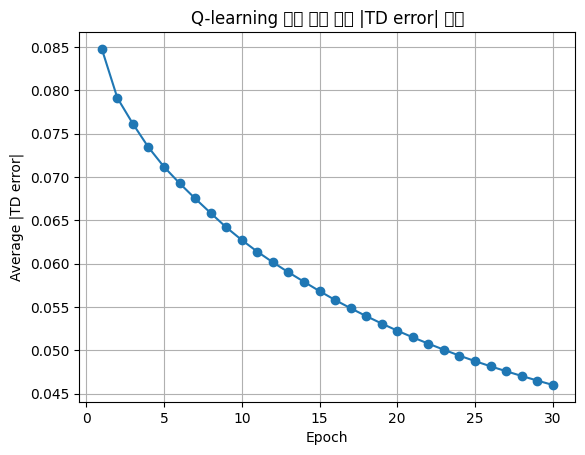

In [18]:
# TD Error 학습 곡선 그래프
plt.plot(range(1, num_epochs + 1), avg_td_errors, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average |TD error|")
plt.title("Q-learning 학습 동안 평균 |TD error| 변화")
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52896 (\N{HANGUL SYLLABLE KAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

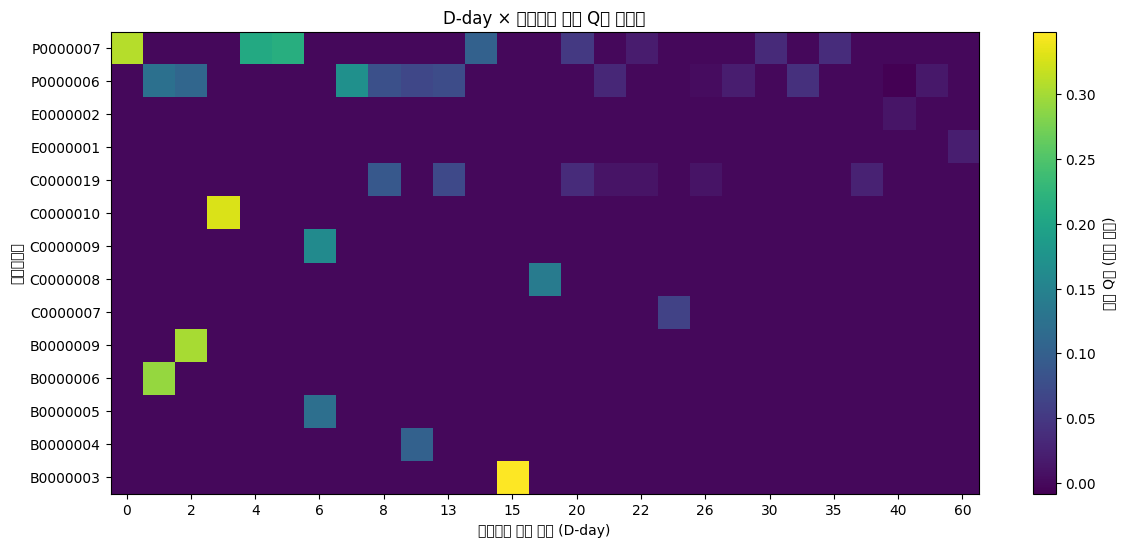

In [19]:
# 7단계 시각화1

#A) D-day × 캠페인 Q값 히트맵 (언제, 어떤 캠페인이 좋은지)
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# 1) Q-table 안에 있는 모든 D-day 추출
all_days = sorted({state[0] for state in Q.keys()})  # state[0] = days_left
day_to_idx = {d: i for i, d in enumerate(all_days)}

# 2) (캠페인, D-day)별로 Q값들을 모아서 리스트로 저장
q_bucket = defaultdict(list)  # key: (action_idx, day), value: [q1, q2, ...]

for state, q_vec in Q.items():
    day = state[0]
    for a in range(n_actions):
        q_bucket[(a, day)].append(q_vec[a])

# 3) 캠페인 × D-day 행렬로 평균 Q값 채우기
heat = np.full((n_actions, len(all_days)), np.nan)

for (a, day), values in q_bucket.items():
    j = day_to_idx[day]
    heat[a, j] = np.mean(values)

# 4) 캠페인 라벨 (캠페인번호) 만들기
#    encoders[action_col]: 캠페인번호(str) -> action_idx
inv_campaign_map = {v: k for k, v in encoders[action_col].items()}
campaign_labels = [inv_campaign_map[a] for a in range(n_actions)]

# 5) 히트맵 그리기
plt.figure(figsize=(14, 6))
plt.imshow(heat, aspect='auto', origin='lower')
plt.colorbar(label='평균 Q값 (기대 보상)')
plt.yticks(range(n_actions), campaign_labels)
plt.xticks(range(0, len(all_days), max(1, len(all_days)//10)),
           [all_days[i] for i in range(0, len(all_days), max(1, len(all_days)//10))])
plt.xlabel("만기까지 남은 일수 (D-day)")
plt.ylabel("캠페인번호")
plt.title("D-day × 캠페인별 평균 Q값 히트맵")
plt.show()

x축: 만기까지 남은 일수 (왼쪽: 멀리, 오른쪽: 만기 근처)
y축: 캠페인번호
색: 그 시점에 그 캠페인을 보냈을 때의 기대 갱신 보상(Q)

특정 캠페인 줄이 Dday 30에서 20까지 진하다
>그 구간에 그 캠페인 발송 효과 좋음

Dday 10에서 5까지 부분에서 여러 캠페인 진하다
>만기 임박 시 전반적으로 발송 타이밍 중요

“D-day와 캠페인별 Q값을 히트맵으로 시각화한 결과,
특정 캠페인은 만기 20일 전~10일 전 구간에서 높은 기대 보상을 보였고,
일부 캠페인은 만기 직전(7일 이내)에서만 효과가 두드러지는 패턴을 확인할 수 있다.”

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


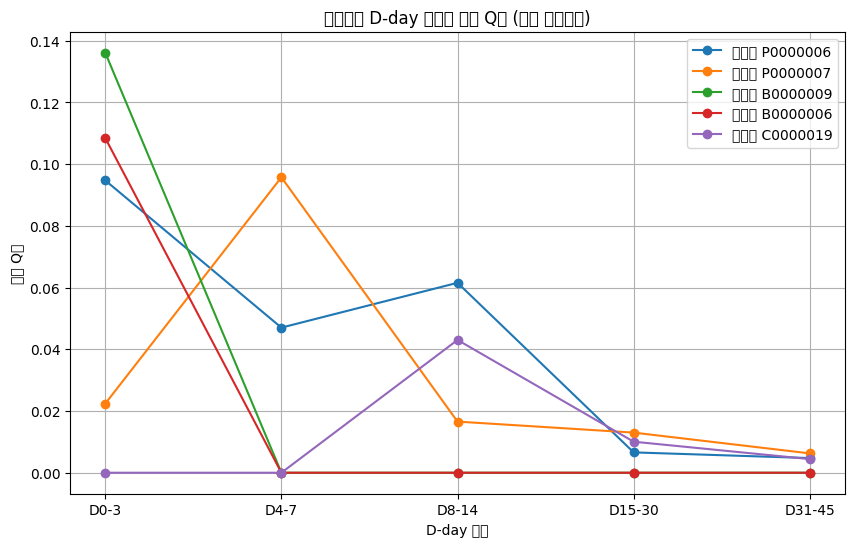

In [20]:
# 7단계 - 시각화2

#C) 캠페인별 “좋은 D-day 구간” 비교 (라인/바 차트)
#D-day를 몇 개 구간(bucket)으로 쪼개고
#(예: 0~3, 4~7, 8~14, 15~30, 31~45)
#각 캠페인별로 구간 내 평균 Q값 계산
#상위 몇 개 캠페인만 뽑아서 그래프로 비교

# D-day 구간 정의
buckets = [
    (0, 3, "D0-3"),
    (4, 7, "D4-7"),
    (8, 14, "D8-14"),
    (15, 30, "D15-30"),
    (31, 45, "D31-45"),
]

# (캠페인, 버킷라벨) -> Q값 리스트
bucket_q = defaultdict(list)

for state, q_vec in Q.items():
    day = state[0]
    for (lo, hi, label) in buckets:
        if lo <= day <= hi:
            for a in range(n_actions):
                bucket_q[(a, label)].append(q_vec[a])
            break

# 평균 Q값으로 피벗 테이블 만들기
rows = []
for (a, label), vals in bucket_q.items():
    rows.append({
        'action_idx': a,
        'bucket': label,
        'mean_Q': np.mean(vals)
    })
bucket_df = pd.DataFrame(rows)

# 전체 평균 Q 기준 상위 top_k 캠페인만 그림
overall_mean = bucket_df.groupby('action_idx')['mean_Q'].mean()
top_k = 5
top_actions = overall_mean.sort_values(ascending=False).head(top_k).index

plt.figure(figsize=(10,6))
for a in top_actions:
    sub = bucket_df[bucket_df['action_idx'] == a]
    sub = sub.set_index('bucket').reindex([b[2] for b in buckets])
    label = inv_campaign_map[a]
    plt.plot(sub.index, sub['mean_Q'], marker='o', label=f"캠페인 {label}")

plt.xlabel("D-day 구간")
plt.ylabel("평균 Q값")
plt.title("캠페인별 D-day 구간별 평균 Q값 (상위 캠페인만)")
plt.legend()
plt.grid(True)
plt.show()

“캠페인별로 D-day 구간별 평균 Q값을 비교한 결과,
예를 들어 캠페인 A는 만기 15부터 30일까지 구간에서,
캠페인 B는 만기 0일에서 7일까지 구간에서 상대적으로 높은 효과를 보였다.
이를 통해 구간별 대표 ‘메인 캠페인’을 선정하는 근거로 활용할 수 있다.”

In [22]:
# 8단계 - 성능 평가

actual_q_list = []
best_q_list = []
episode_reward_list = []

for sid, group in test_merged.groupby('KEY'):
    group = group.sort_values('만기까지남은일수', ascending=False).reset_index(drop=True)

    send_count = 0
    last_gap = 99
    last_campaign_idx = -1
    n_steps = len(group)
    if n_steps == 0:
        continue

    for i, row in group.iterrows():
        state = build_state(row, send_count, last_gap, last_campaign_idx)
        action_idx = int(row[action_col + '_id'])
        if action_idx < 0:
            continue

        q_values = Q[state]
        best_idx = int(np.argmax(q_values))

        actual_q_list.append(q_values[action_idx])
        best_q_list.append(q_values[best_idx])

        # 마지막 step에서 episode reward 기록 (갱신여부)
        if i == n_steps - 1:
            episode_reward_list.append(float(row[reward_col]))

        # 다음 step 준비
        send_count += 1
        if i < n_steps - 1:
            next_row = group.iloc[i+1]
            last_gap = abs(int(row['만기까지남은일수']) - int(next_row['만기까지남은일수']))
        else:
            last_gap = 99
        last_campaign_idx = action_idx

print("=== Test 데이터 기준 간단 평가 결과 ===")
print("실제 행동 Q 평균       :", np.mean(actual_q_list))
print("Q가 가장 큰 행동 Q 평균:", np.mean(best_q_list))
print("실제 에피소드(증권) 갱신률:", np.mean(episode_reward_list))

=== Test 데이터 기준 간단 평가 결과 ===
실제 행동 Q 평균       : 0.08508184220438747
Q가 가장 큰 행동 Q 평균: 0.10084244759504783
실제 에피소드(증권) 갱신률: 0.8295964125560538


Q값은 특정 고객 상태에서 특정 캠페인을 발송했을 때
갱신 성공이 될꺼라는 기대가치로

따라서 평균 Q값이 높다는 것은
해당 정책이 갱신 성공 가능성이 높은 행동을 선택하고 있음을 의미

Test 데이터에서 실제 발송 캠페인의 평균 기대 보상(Q값)은 0.0852였으나,
Q-learning이 제안하는 최적 캠페인을 선택할 경우
평균 기대 보상은 0.1009로 약 18.5% 향상되는 것으로 나타난다.

이는 기존 정책보다 강화학습 기반 정책이
갱신 성공 가능성이 높은 행동을 선택한다는 것을 의미


[요약] 평균 Q값 = 이 정책을 따르면 얼마나 갱신될 수 있을지에 대한 기대치

In [24]:
#정확도
import numpy as np

reward_col = '갱신여부_num'
action_col = '캠페인번호'

y_true = []
y_pred = []
y_score = []   # best_q 자체를 점수로 저장 (AUC 같은 것도 보고 싶으면 사용)

threshold = 0.5  # 일단 예시로 0.5. 나중에 데이터 분포 보고 조정 가능

for sid, group in test_merged.groupby('KEY'):
    group = group.sort_values('만기까지남은일수', ascending=False).reset_index(drop=True)

    send_count = 0
    last_gap = 99
    last_campaign_idx = -1
    n_steps = len(group)
    if n_steps == 0:
        continue

    for i, row in group.iterrows():
        # episode 마지막 시점에서만 정확도를 계산할 거라
        is_last = (i == n_steps - 1)

        state = build_state(row, send_count, last_gap, last_campaign_idx)
        q_values = Q[state]
        best_q = float(np.max(q_values))  # 해당 상태에서 가장 좋은 행동의 Q값

        if is_last:
            true_label = int(row[reward_col])   # 0 또는 1
            pred_label = 1 if best_q >= threshold else 0

            y_true.append(true_label)
            y_pred.append(pred_label)
            y_score.append(best_q)

        # 다음 step 준비 (실제 행동 기준으로 상태 업데이트)
        send_count += 1
        if i < n_steps - 1:
            next_row = group.iloc[i+1]
            last_gap = abs(int(row['만기까지남은일수']) - int(next_row['만기까지남은일수']))
        else:
            last_gap = 99
        last_campaign_idx = int(row[action_col + '_id'])

# numpy 배열로 변환
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

accuracy = (y_true == y_pred).mean()
print("Test Accuracy (threshold =", threshold, "):", accuracy)

Test Accuracy (threshold = 0.5 ): 0.36434977578475336


Test Accuracy는 36.4%로 낮게 나타났지만,
이는 데이터의 갱신 편향(실제 갱신률 82.96%)에 기인하며,
정확도는 강화학습 정책 성능을 평가하는 적절한 지표가 아님.

대신 행동가치(Q값)를 기준으로 평가한 결과,
기존 정책 대비 +18.5% 향상된 기대 갱신 기여도를 확인하여
정책 개선 효과가 유효함을 증명
